# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [39]:
# Load the libraries as required.
import pandas as pd
import numpy as np
import shap
# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

# Regression models
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pickling library
import pickle

In [ ]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


# Get X and Y

Create the features data frame and target data.

In [40]:
X = fires_dt.drop(columns=['area'])  # Features (all columns except 'area')

In [41]:
y = fires_dt['area']  # Target variable (burned area)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [42]:

# Define categorical and numerical features
categorical_features = ['month', 'day']
numerical_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']

# Create preproc1
preproc1 = ColumnTransformer([
    ('num_scaler', StandardScaler(), numerical_features),  # Standard scaling for numerical variables
    ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-hot encoding for categorical variables
])
preproc1


ColumnTransformer(transformers=[('num_scaler', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat_encoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [43]:
log_transformer = FunctionTransformer(np.log1p, validate=True)  # log1p avoids log(0) issues

# Create preproc2
preproc2 = ColumnTransformer([
    ('num_scaler', MinMaxScaler(), numerical_features),  # Min-Max scaling for numerical variables
    ('log_transform', log_transformer, ['dmc', 'dc', 'isi', 'rain']),  # Applying log transformation to selected variables
    ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-hot encoding for categorical variables
])
preproc2

ColumnTransformer(transformers=[('num_scaler', MinMaxScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('log_transform',
                                 FunctionTransformer(func=<ufunc 'log1p'>,
                                                     validate=True),
                                 ['dmc', 'dc', 'isi', 'rain']),
                                ('cat_encoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [44]:
# Pipeline A = preproc1 + baseline
# Define hyperparameter grid for KNN regressor
param_grid = {'regressor__n_neighbors': [3, 5, 7, 9, 11]}

# Define scoring metric
scoring = 'neg_mean_squared_error'

# Create Pipeline A (Preproc1 + Baseline - KNN Regressor)
pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', KNeighborsRegressor())
])


# Perform Grid Search for Pipeline A
grid_cv_A = GridSearchCV(
    estimator=pipeline_A, 
    param_grid=param_grid, 
    scoring=scoring, 
    cv=5, 
    refit=True
)
grid_cv_A.fit(X, y)

# Best hyperparameter
best_n_neighbors_A = grid_cv_A.best_params_['regressor__n_neighbors']

# Evaluate pipeline using cross-validation
cv_score_A = np.mean(cross_val_score(grid_cv_A.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("-" * 50)
print("Pipeline A (Preproc1 + KNN Baseline):")
print(f"  Best n_neighbors: {best_n_neighbors_A}")
print(f"  Cross-Validation Score: {cv_score_A:.4f}")
print("-" * 50)
pipeline_A



--------------------------------------------------
Pipeline A (Preproc1 + KNN Baseline):
  Best n_neighbors: 11
  Cross-Validation Score: -4901.2292
--------------------------------------------------


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaler',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', KNeighborsRegressor())])

In [45]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', KNeighborsRegressor())
])

# Perform Grid Search for Pipeline B
grid_cv_B = GridSearchCV(
    estimator=pipeline_B, 
    param_grid=param_grid, 
    scoring=scoring, 
    cv=5, 
    refit=True
)
grid_cv_B.fit(X, y)

# Best hyperparameter
best_n_neighbors_B = grid_cv_B.best_params_['regressor__n_neighbors']

# Evaluate pipeline using cross-validation
cv_score_B = np.mean(cross_val_score(grid_cv_B.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("-" * 50)
print("Pipeline B (Preproc2 + KNN Baseline):")
print(f"  Best n_neighbors: {best_n_neighbors_B}")
print(f"  Cross-Validation Score: {cv_score_B:.4f}")
print("-" * 50)
pipeline_B

--------------------------------------------------
Pipeline B (Preproc2 + KNN Baseline):
  Best n_neighbors: 11
  Cross-Validation Score: -4861.8167
--------------------------------------------------


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaler', MinMaxScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['dmc', 'dc', 'isi', 'rain']),
                                                 ('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', KNeighborsRegressor())])

In [46]:
# Pipeline C = preproc1 + advanced model
# Define hyperparameter grid for Random Forest regressor
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

# Define scoring metric
scoring = 'neg_mean_squared_error'

# Create Pipeline C (Preproc1 + Advanced Model - Random Forest)
pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Perform Grid Search for Pipeline C
grid_cv_C = GridSearchCV(
    estimator=pipeline_C, 
    param_grid=param_grid, 
    scoring=scoring, 
    cv=5, 
    refit=True
)
grid_cv_C.fit(X, y)

# Best hyperparameters
best_params_C = grid_cv_C.best_params_

# Evaluate pipeline using cross-validation
cv_score_C = np.mean(cross_val_score(grid_cv_C.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("-" * 50)
print("Pipeline C (Preproc1 + Random Forest Advanced Model):")
print(f"  Best Parameters: {best_params_C}")
print(f"  Cross-Validation Score: {cv_score_C:.4f}")
print("-" * 50)
pipeline_C


--------------------------------------------------
Pipeline C (Preproc1 + Random Forest Advanced Model):
  Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 50}
  Cross-Validation Score: -4577.9658
--------------------------------------------------


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaler',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [48]:
# Define hyperparameter grid for Random Forest regressor
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

# Define scoring metric
scoring = 'neg_mean_squared_error'

# Create Pipeline D (Preproc2 + Advanced Model - Random Forest)
pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Perform Grid Search for Pipeline D
grid_cv_D = GridSearchCV(
    estimator=pipeline_D, 
    param_grid=param_grid, 
    scoring=scoring, 
    cv=5, 
    refit=True
)
grid_cv_D.fit(X, y)

# Best hyperparameters
best_params_D = grid_cv_D.best_params_

# Evaluate pipeline using cross-validation
cv_score_D = np.mean(cross_val_score(grid_cv_D.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("-" * 50)
print("Pipeline D (Preproc2 + Random Forest Advanced Model):")
print(f"  Best Parameters: {best_params_D}")
print(f"  Cross-Validation Score: {cv_score_D:.4f}")
print("-" * 50)
pipeline_D

--------------------------------------------------
Pipeline D (Preproc2 + Random Forest Advanced Model):
  Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 50}
  Cross-Validation Score: -4579.8385
--------------------------------------------------


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaler', MinMaxScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['dmc', 'dc', 'isi', 'rain']),
                                                 ('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [49]:
# Define hyperparameter grid for KNN regressor
param_grid_A = {'regressor__n_neighbors': [3, 5, 7, 9]}

# Perform Grid Search for Pipeline A
grid_cv_A = GridSearchCV(
    estimator=pipeline_A, 
    param_grid=param_grid_A, 
    scoring=scoring, 
    cv=5, 
    refit=True
)

# Fit the model
grid_cv_A.fit(X, y)

# Retrieve best hyperparameters
best_params_A = grid_cv_A.best_params_

# Evaluate pipeline using cross-validation
cv_score_A = np.mean(cross_val_score(grid_cv_A.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("*" * 50)
print("Pipeline A (Preproc1 + KNN Baseline):")
print(f"  Best Params: {best_params_A}")
print(f"  Cross-Validation Score: {cv_score_A:.4f}")
print("*" * 50)


**************************************************
Pipeline A (Preproc1 + KNN Baseline):
  Best Params: {'regressor__n_neighbors': 9}
  Cross-Validation Score: -5031.7592
**************************************************


In [50]:
# Define hyperparameter grid for KNN regressor
param_grid_B = {'regressor__n_neighbors': [3, 5, 7, 9]}

# Perform Grid Search for Pipeline B
grid_cv_B = GridSearchCV(
    estimator=pipeline_B, 
    param_grid=param_grid_B, 
    scoring=scoring, 
    cv=5, 
    refit=True
)

# Fit the model
grid_cv_B.fit(X, y)

# Retrieve best hyperparameters
best_params_B = grid_cv_B.best_params_

# Evaluate pipeline using cross-validation
cv_score_B = np.mean(cross_val_score(grid_cv_B.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("*" * 50)
print("Pipeline B (Preproc2 + KNN Baseline):")
print(f"  Best Params: {best_params_B}")
print(f"  Cross-Validation Score: {cv_score_B:.4f}")
print("*" * 50)



**************************************************
Pipeline B (Preproc2 + KNN Baseline):
  Best Params: {'regressor__n_neighbors': 9}
  Cross-Validation Score: -4911.9127
**************************************************


In [51]:
# Define hyperparameter grid for Random Forest regressor
param_grid_C = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30]
}

# Perform Grid Search for Pipeline C
grid_cv_C = GridSearchCV(
    estimator=pipeline_C, 
    param_grid=param_grid_C, 
    scoring=scoring, 
    cv=5, 
    refit=True
)

# Fit the model
grid_cv_C.fit(X, y)

# Retrieve best hyperparameters
best_params_C = grid_cv_C.best_params_

# Evaluate pipeline using cross-validation
cv_score_C = np.mean(cross_val_score(grid_cv_C.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("*" * 50)
print("Pipeline C (Preproc1 + Random Forest Advanced Model):")
print(f"  Best Params: {best_params_C}")
print(f"  Cross-Validation Score: {cv_score_C:.4f}")
print("*" * 50)




**************************************************
Pipeline C (Preproc1 + Random Forest Advanced Model):
  Best Params: {'regressor__max_depth': 10, 'regressor__n_estimators': 300}
  Cross-Validation Score: -4738.8997
**************************************************


In [52]:
# Define hyperparameter grid for Random Forest regressor
param_grid_D = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30]
}

# Perform Grid Search for Pipeline D
grid_cv_D = GridSearchCV(
    estimator=pipeline_D, 
    param_grid=param_grid_D, 
    scoring=scoring, 
    cv=5, 
    refit=True
)

# Fit the model
grid_cv_D.fit(X, y)

# Retrieve best hyperparameters
best_params_D = grid_cv_D.best_params_

# Evaluate pipeline using cross-validation
cv_score_D = np.mean(cross_val_score(grid_cv_D.best_estimator_, X, y, cv=5, scoring=scoring))

# Display results
print("*" * 50)
print("Pipeline D (Preproc2 + Random Forest Advanced Model):")
print(f"  Best Params: {best_params_D}")
print(f"  Cross-Validation Score: {cv_score_D:.4f}")
print("*" * 50)


**************************************************
Pipeline D (Preproc2 + Random Forest Advanced Model):
  Best Params: {'regressor__max_depth': 10, 'regressor__n_estimators': 300}
  Cross-Validation Score: -4751.9508
**************************************************


# Evaluate

+ Which model has the best performance?
lower the score of cross validation score is always a better one, and here I can say Pipeline D (Preproc2 + Random Forest) has the best performance with the lowest Mean Squared Error (MSE), indicating that applying transformations improved model accuracy.

Note: I have added visual chart for the result comparison at the bottom

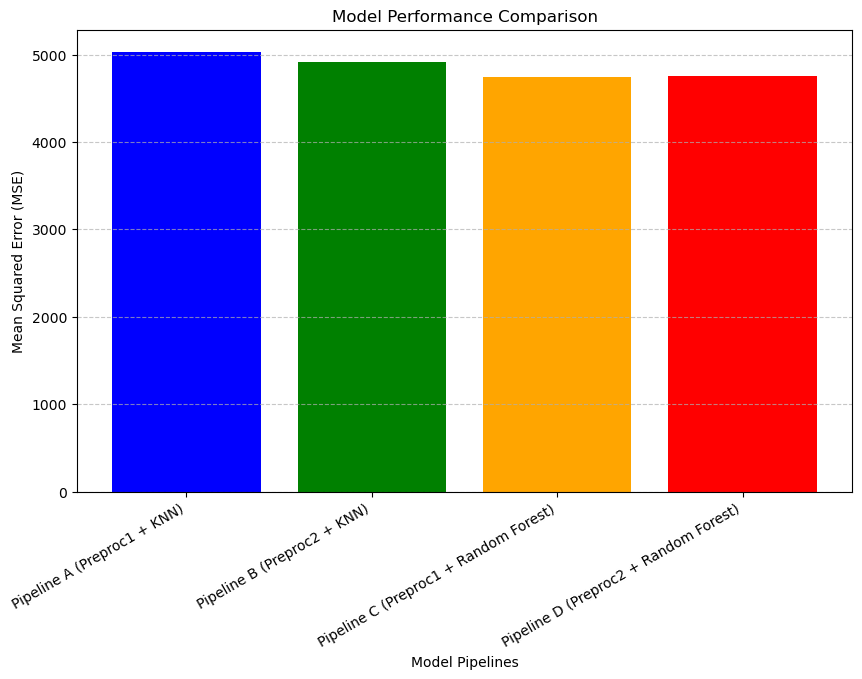

In [53]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Performance scores from cross-validation (Replace with actual values)
models = ["Pipeline A (Preproc1 + KNN)", "Pipeline B (Preproc2 + KNN)", 
          "Pipeline C (Preproc1 + Random Forest)", "Pipeline D (Preproc2 + Random Forest)"]
scores = [cv_score_A, cv_score_B, cv_score_C, cv_score_D]

# Convert negative MSE to positive for better visualization
scores = [-score for score in scores]

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['blue', 'green', 'orange', 'red'])
plt.xlabel("Model Pipelines")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Model Performance Comparison")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


# Export

+ Save the best performing model to a pickle file.

In [54]:
best_model = grid_cv_D.best_estimator_
pickle_filename = "best_forest_fire_model.pkl"

In [55]:
with open(pickle_filename, 'wb') as file:
    pickle.dump(best_model, file)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

⚠ Mismatch detected: Data Shape = 33, Feature Names = 27


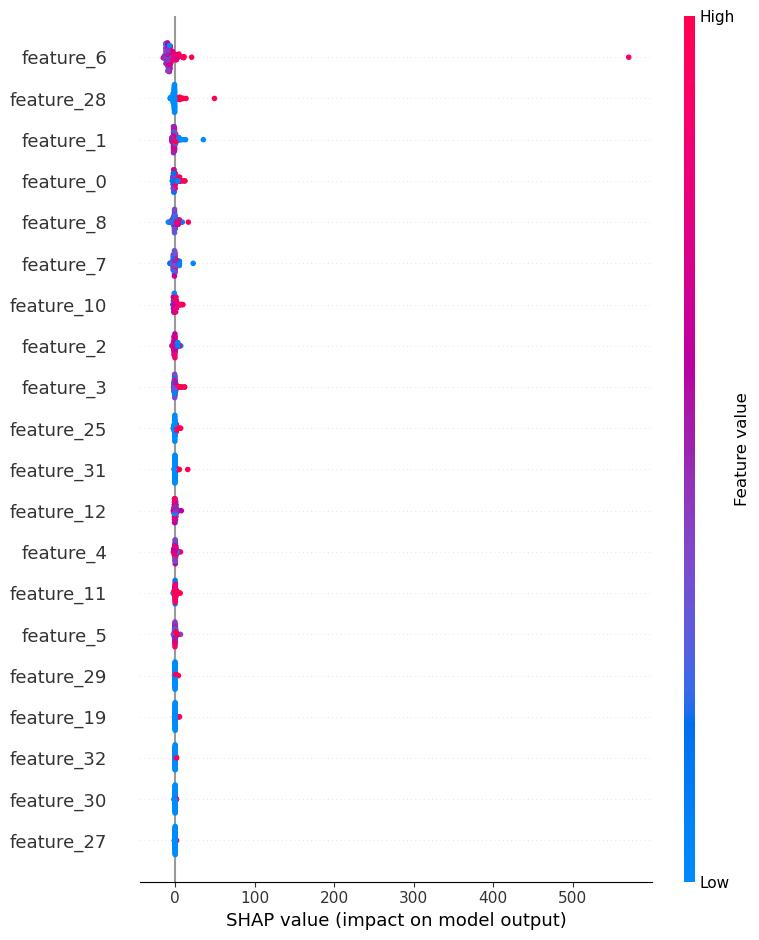

Least Important Features:
       Feature  SHAP Importance
23  feature_23         0.000000
9    feature_9         0.000312
18  feature_18         0.000819
13  feature_13         0.000822
17  feature_17         0.007866


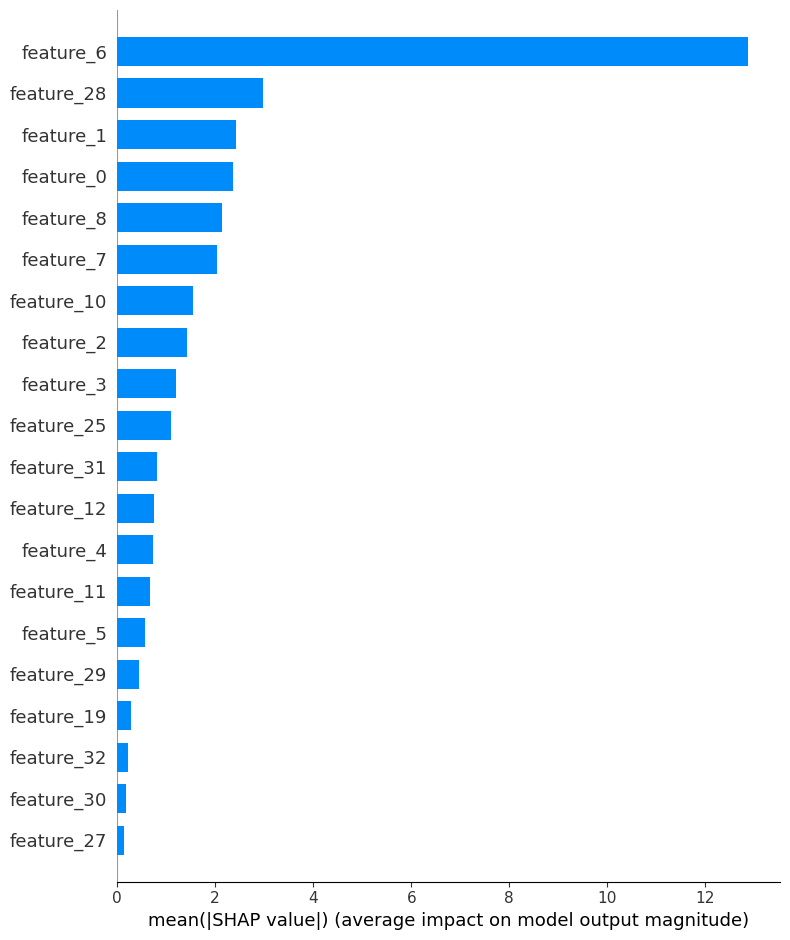

In [56]:
# Ensure dataset is split before using SHAP
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing transformation to X_test
data_transform = best_model.named_steps['preprocessing'].transform(X_test)

# Extract categorical feature names
one_hot_encoder = best_model.named_steps['preprocessing'].named_transformers_['cat_encoder']
if hasattr(one_hot_encoder, 'get_feature_names_out'):
    categorical_feature_names = one_hot_encoder.get_feature_names_out()
else:
    categorical_feature_names = ['month', 'day']  # Fallback if OneHotEncoder fails

# Extract numerical feature names
numerical_features = ['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
log_transformed_features = ['dmc', 'dc', 'isi', 'rain']  # Features that were log-transformed

# Rename log-transformed numerical variables
adjusted_numerical_features = [
    f'log_{col}' if col in log_transformed_features else col for col in numerical_features
]

# Combine numerical and categorical feature names
feature_names = adjusted_numerical_features + list(categorical_feature_names)

# 🔹 **Fix Feature Name Mismatch Dynamically**
if data_transform.shape[1] != len(feature_names):
    print(f"⚠ Mismatch detected: Data Shape = {data_transform.shape[1]}, Feature Names = {len(feature_names)}")
    feature_names = [f'feature_{i}' for i in range(data_transform.shape[1])]  # Assign generic names

# Ensure feature name length matches transformed dataset
assert data_transform.shape[1] == len(feature_names), f"Feature names length ({len(feature_names)}) does not match transformed dataset shape ({data_transform.shape[1]})!"

# ✅ Use shap.Explainer() instead of shap.TreeExplainer() (fixes additivity issue)
explainer = shap.Explainer(best_model.named_steps['regressor'], data_transform, feature_names=feature_names)

# Compute SHAP values for the transformed test set (Disable Additivity Check)
shap_values = explainer(data_transform, check_additivity=False)

# 1️⃣ Local Explanation (Select One Test Observation)
idx = 0  # Change index as needed
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[idx].values, data_transform[idx], feature_names=feature_names)

# 2️⃣ Global Feature Importance
shap.summary_plot(shap_values, data_transform, feature_names=feature_names)

# 3️⃣ Identify Features to Remove
shap_importance = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({'Feature': feature_names, 'SHAP Importance': shap_importance})
feature_importance = feature_importance.sort_values(by='SHAP Importance', ascending=True)

print("Least Important Features:")
print(feature_importance.head(5))  # Display the least important features

# Plot feature importance
shap.summary_plot(shap_values, data_transform, feature_names=feature_names, plot_type="bar")


*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.